[Современные сверточные сети](https://d2l.ai/chapter_convolutional-modern/index.html "Дополнительный материал")

[Материалы по теме](https://github.com/netology-ds-team/DLL/tree/main/DLL-materials "Учебные блокноты с ГидХаба")

In [1]:
import torch, pandas as pd, numpy as np, time
import matplotlib.pyplot as plt
import random
import torchvision as tv

## Загрузка данных

100%|██████████| 562M/562M [00:02<00:00, 227MB/s]


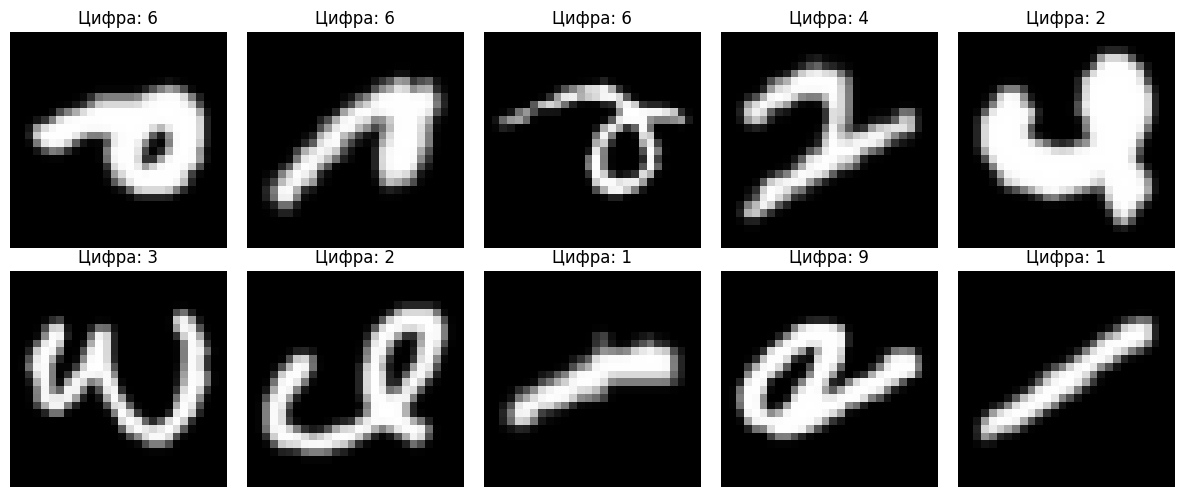

In [2]:
import torchvision.datasets as datasets
# Загрузка EMNIST (цифры) без преобразований
digits_emnist = datasets.EMNIST(
    root='./data',
    split='digits',
    train=True,
    download=True,
    transform=None  # Без преобразований
)

# Названия классов для EMNIST split='digits' (цифры 0–9)
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# 10 случайных индексов
random_indices = random.sample(range(len(digits_emnist)), 10)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

# Отображение выбранных изображений
for i, idx in enumerate(random_indices):
    img, label = digits_emnist[idx]
    # Преобразуем PIL изображение в массив numpy
    img_np = np.array(img)

    # Отображение изображения
    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(f"Цифра: {class_names[label]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [3]:
# В случаи если требуется изменить размерность изображений: Подготовка трансформера(в данном случае получение тензора 224*224 и тремя каналами)
transoforms = tv.transforms.Compose([
    tv.transforms.Grayscale(3),
    tv.transforms.Resize((224, 224)),
    tv.transforms.ToTensor()
])

In [4]:
# dataset без трансформации.
train_dataset = tv.datasets.EMNIST('.', train=True, transform=tv.transforms.ToTensor(), download=True, split='digits')
test_dataset = tv.datasets.EMNIST('.', train=False, transform=tv.transforms.ToTensor(), download=True, split='digits')

100%|██████████| 562M/562M [00:07<00:00, 70.5MB/s]


In [5]:
train_Loader = torch.utils.data.DataLoader(train_dataset, batch_size=256)
test_Loader = torch.utils.data.DataLoader(test_dataset, batch_size=256)

In [6]:
for images, labels in train_Loader:
  print(f"Размер батча: {images.shape}")
  print(f"Размер одного изображения: {images[0].shape}")
  break  # Выходим после первого батча

print(f'Общее количество батчей: {len(train_Loader)}\n'
      f'Общее количество изображений в датасете: {len(train_Loader.dataset)}\n')

Размер батча: torch.Size([256, 1, 28, 28])
Размер одного изображения: torch.Size([1, 28, 28])
Общее количество батчей: 938
Общее количество изображений в датасете: 240000



##VGG16

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [8]:
model_VGG16 = tv.models.vgg16(pretrained=False) #  не предобученная модель!

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [9]:
model_VGG16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [10]:
from torchsummary import summary

In [11]:
# Огромное число необученных параметров 138,357,544
# Принято решение для изображений 28*28 с 1 каналам создать кастомную, модефицированную модель немного сожей архитектурой
summary(model_VGG16.to(device), input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [12]:
model_VGG16.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [13]:
model_VGG16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

## СВОЯ КАСТОМНАЯ МОДЕЛЬ VGG с сохранением сути, сформировано три блока, размер свертки одинаковый 3*3

In [14]:
from torch.nn import Dropout
def my_custom_model_vgg(pretrained=False, num_classes=10):
  model = tv.models.vgg16(pretrained=pretrained)

  # Изменяем параметры первого слоя: на вход 1 канал, выходное изображение остается 28*28, но 64 канала
  model.features[0] = torch.nn.Conv2d(in_channels=1, out_channels=64, kernel_size=(3,3), stride=1, padding=1)

  # Вместо 5 блоков кастомизирую модель в 3 блока
  features = [] # пустой блок

  # БЛОК_1
  features += [torch.nn.Conv2d(in_channels=1, out_channels=64, kernel_size=(3,3), stride=1, padding=1)] # это второй слой (первый слой блока уже определен выше)
  features += [torch.nn.ReLU(inplace=True)]
  features += [torch.nn.MaxPool2d(kernel_size=(2, 2), stride=2)] # уменьшение размерности с 28 на 14

  # БЛОК_2
  features += [torch.nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3,3), stride=1, padding=1)] # увеличиваем число каналов в 2 раза, до 128
  features += [torch.nn.ReLU(inplace=True)]
  features += [torch.nn.MaxPool2d(kernel_size=(2, 2), stride=2)] # уменьшение размерности с 14 на 7

  # БЛОК_3
  features += [torch.nn.Conv2d(in_channels=128, out_channels=256, kernel_size=(3,3), stride=1, padding=1)] # увеличиваем число каналов в 2 раза, до 128
  features += [torch.nn.ReLU(inplace=True)]
  # Решил убрать из блока макспулинг
  #features += [torch.nn.MaxPool2d(kernel_size=(2, 2), stride=1, padding=1)] # Выполняю макспулинг с целью сохранения логики модели vgg16, но страйт - 1, т.к уменьшать размер уже некуда

  model.features = torch.nn.Sequential(*features)

  # Кастомизирую классификатор под новый размер активации

  model.classifier = torch.nn.Sequential(
      torch.nn.Linear(in_features=7*7*256, out_features=512), # Входных признаков = число каналов * выходное изображение 7*7. Число нейронов на выходе 512
      torch.nn.ReLU(inplace=True),
      torch.nn.Dropout(0.5),
      torch.nn.Linear(in_features=512, out_features=num_classes) # Количество выходов 10 (по умолчании)
  )
  return model

In [15]:
# Создаю свою кастомную модель через функцию
custom_model_vgg =  my_custom_model_vgg()

In [16]:
custom_model_vgg

VGG(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(7, 7))
  (classifier): Sequential(
    (0): Linear(in_features=12544, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [17]:
# Количество параметров уменьшено с 138,357,544 до 6,797,834 (в 20 раз), c 39 до 13 слоев.
summary(custom_model_vgg.to(device), input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 28, 28]             640
              ReLU-2           [-1, 64, 28, 28]               0
         MaxPool2d-3           [-1, 64, 14, 14]               0
            Conv2d-4          [-1, 128, 14, 14]          73,856
              ReLU-5          [-1, 128, 14, 14]               0
         MaxPool2d-6            [-1, 128, 7, 7]               0
            Conv2d-7            [-1, 256, 7, 7]         295,168
              ReLU-8            [-1, 256, 7, 7]               0
 AdaptiveAvgPool2d-9            [-1, 256, 7, 7]               0
           Linear-10                  [-1, 512]       6,423,040
             ReLU-11                  [-1, 512]               0
          Dropout-12                  [-1, 512]               0
           Linear-13                   [-1, 10]           5,130
Total params: 6,797,834
Trainable param

## Обучение модели

In [18]:
# Фнкция потерь.
loss = torch.nn.CrossEntropyLoss()

In [19]:
def optimizer(model, lr=0.01):
  return torch.optim.Adam(model.parameters(), lr=lr) # weight_decay=1e-5 - L2 регуляризация

In [20]:
def train_model(model, optimizer_, num_epochs=10):
    train_losses = []
    val_losses = []

    # Определяем устройство
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)  # Перемещаем модель на устройство

    for ep in range(num_epochs):
        # Обучение (train)
        train_iters, train_passed = 0, 0
        train_loss, train_acc = 0., 0.
        start = time.time()

        model.train()
        for X, y in train_Loader: # ДАННЫЕ ДЛЯ ОБУЧЕНИЯ
            X = X.to(device)  # Переносим на устройство
            y = y.to(device)  # Переносим на устройство

            optimizer_.zero_grad()
            y_pred = model(X)
            l = loss(y_pred, y)
            l.backward()
            optimizer_.step()
            train_loss += l.item()
            train_acc += (y_pred.argmax(dim=1) == y).sum().item()
            train_iters += 1
            train_passed += len(X)

        # Валидация (test)
        test_iters, test_passed = 0, 0
        test_loss, test_acc = 0., 0.
        model.eval()
        with torch.no_grad():  # Отключаем вычисление градиентов
            for X, y in test_Loader:      # ТЕСТОВЫЕ ДАННЫЕ
                X = X.to(device)  # Обязательно переносим на устройство!
                y = y.to(device)  # Обязательно переносим на устройство!

                y_pred = model(X)
                l = loss(y_pred, y)
                test_loss += l.item()
                test_acc += (y_pred.argmax(dim=1) == y).sum().item()
                test_iters += 1
                test_passed += len(X)

        # Усредняем потери
        avg_train_loss = train_loss / train_iters
        avg_test_loss = test_loss / test_iters

        train_losses.append(avg_train_loss)
        val_losses.append(avg_test_loss)

        print("ep: {}, taked: {:.3f}, train_loss: {:.4f}, train_acc: {:.4f}, test_loss: {:.4f}, test accuracy: {:.4f}".format(
            ep,
            time.time() - start,
            avg_train_loss,
            train_acc / train_passed,
            avg_test_loss,
            test_acc / test_passed
        ))

    return train_losses, val_losses

In [21]:
trainer_1 = optimizer(model=custom_model_vgg, lr=0.001)

In [22]:
import pickle
import json

# ОБУЧЕНИЕ
train_losses, val_losses = train_model(
    model=custom_model_vgg,
    optimizer_=trainer_1,
    num_epochs=10
)

# 2. Сохранение в JSON
with open('results_custom_model_vgg.json', 'w') as f:
    json.dump({
        'train_losses': train_losses,
        'val_losses': val_losses
    }, f, indent=4)

ep: 0, taked: 49.204, train_loss: 0.0793, train_acc: 0.9759, test_loss: 0.0286, test accuracy: 0.9916
ep: 1, taked: 53.010, train_loss: 0.0259, train_acc: 0.9926, test_loss: 0.0204, test accuracy: 0.9943
ep: 2, taked: 49.413, train_loss: 0.0185, train_acc: 0.9949, test_loss: 0.0191, test accuracy: 0.9948
ep: 3, taked: 49.779, train_loss: 0.0150, train_acc: 0.9958, test_loss: 0.0166, test accuracy: 0.9958
ep: 4, taked: 48.888, train_loss: 0.0122, train_acc: 0.9965, test_loss: 0.0176, test accuracy: 0.9952
ep: 5, taked: 48.654, train_loss: 0.0105, train_acc: 0.9970, test_loss: 0.0178, test accuracy: 0.9955
ep: 6, taked: 48.973, train_loss: 0.0087, train_acc: 0.9974, test_loss: 0.0201, test accuracy: 0.9958
ep: 7, taked: 53.517, train_loss: 0.0070, train_acc: 0.9980, test_loss: 0.0188, test accuracy: 0.9960
ep: 8, taked: 50.693, train_loss: 0.0064, train_acc: 0.9980, test_loss: 0.0196, test accuracy: 0.9961
ep: 9, taked: 53.320, train_loss: 0.0051, train_acc: 0.9985, test_loss: 0.0211, te

## Сохранение результатов + ГРАФИКИ

In [23]:
import json

with open('results_custom_model_vgg.json', 'r') as f:
    results = json.load(f)

# Преобразуем в DataFrame для удобного просмотра
df_custom_model_vgg = pd.DataFrame({
    'Epoch': range(len(results['train_losses'])),
    'Train Loss': results['train_losses'],
    'Validation Loss': results['val_losses']
})

df_custom_model_vgg

,Epoch,Train Loss,Validation Loss
0,0,0.079288,0.028648
1,1,0.025865,0.020443
2,2,0.018486,0.019105
3,3,0.014992,0.016648
4,4,0.012186,0.017619
5,5,0.010549,0.017761
6,6,0.008706,0.020118
7,7,0.007047,0.018808
8,8,0.006397,0.019583
9,9,0.005145,0.021112


In [36]:
def chart_plot(df):
  plt.figure(figsize=(10, 6))
  plt.plot(df['Epoch'], df['Train Loss'], label='Train Loss', marker='o')
  plt.plot(df['Epoch'], df['Validation Loss'], label='Validation Loss', marker='s')
  plt.title('Training and Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()

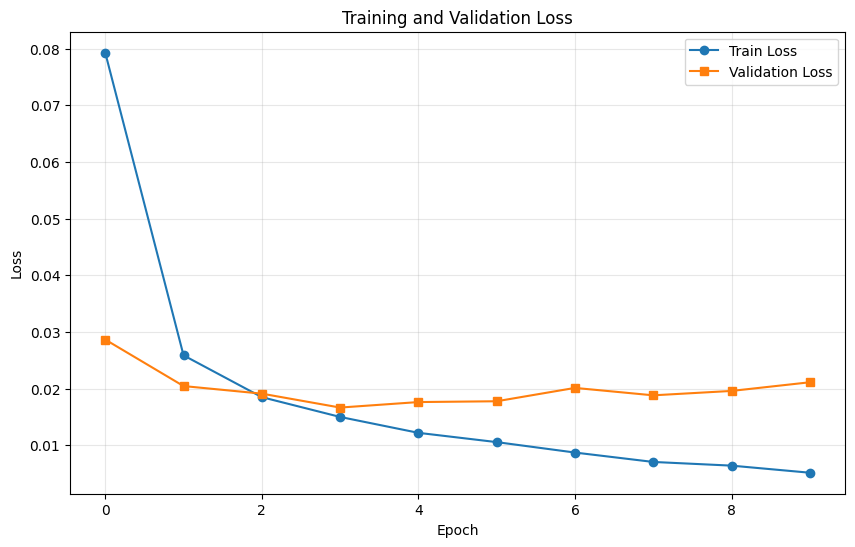

In [37]:
chart_plot(df_custom_model_vgg)

### Модернизированный график

In [27]:
def chart_modern_plot(df):
  # Определение лучшей эпохи (минимальная валидационная потеря)
  best_epoch_idx = df['Validation Loss'].idxmin()
  best_epoch = df.loc[best_epoch_idx, 'Epoch']
  best_val_loss = df.loc[best_epoch_idx, 'Validation Loss']

  plt.figure(figsize=(12, 8))

  # Основной график
  plt.plot(df['Epoch'], df['Train Loss'], label='Train Loss', marker='o', color='blue', alpha=0.7)
  plt.plot(df['Epoch'], df['Validation Loss'], label='Validation Loss', marker='s', color='red', alpha=0.7)

  # Выделение лучшей эпохи
  plt.scatter(best_epoch, best_val_loss, color='red', s=100, zorder=5, edgecolors='black', linewidth=2)
  plt.annotate(
      f'Best: epoch {int(best_epoch)}\nVal Loss: {best_val_loss:.4f}',
      xy=(best_epoch, best_val_loss),
      xytext=(best_epoch + 1, best_val_loss + 0.05),
      arrowprops=dict(arrowstyle='->', color='black'),
      fontsize=10,
      ha='left'
  )

  # Настройки
  plt.title('Ход обучения с указанием наилучшей эпохи', fontsize=16, fontweight='bold')
  plt.xlabel('Epoch', fontsize=12)
  plt.ylabel('Loss', fontsize=12)
  plt.legend(fontsize=11)
  plt.grid(True, alpha=0.3, linestyle='--')
  plt.xticks(df['Epoch'])
  plt.tight_layout()
  plt.show()

  # Выводим информацию о лучшей эпохе
  print(f"Лучшая эпоха: {int(best_epoch)}")
  print(f"Минимальная валидационная потеря: {best_val_loss:.4f}")

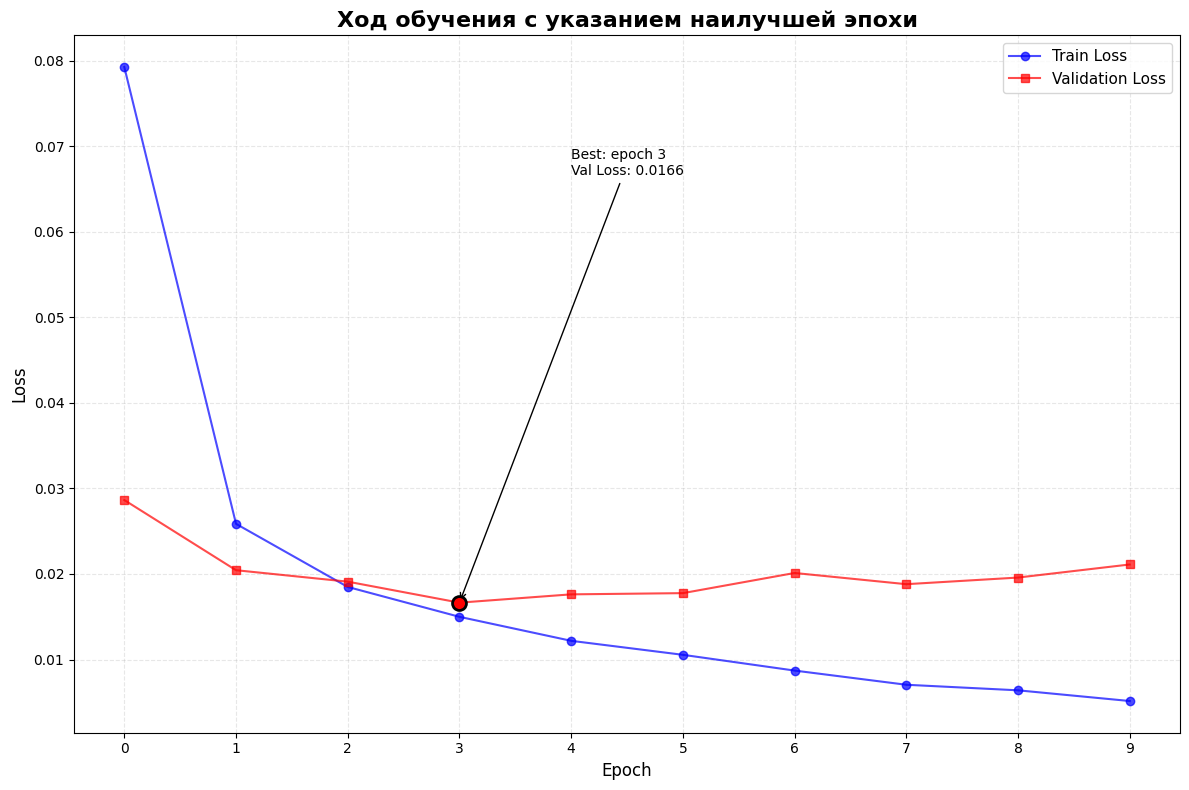

Лучшая эпоха: 3
Минимальная валидационная потеря: 0.0166


In [28]:
chart_modern_plot(df_custom_model_vgg)

## СРАВНЕНИЕ ДВУХ МОДЕЛЕЙ

In [29]:
# Загрузка результата из предыдущего блокнота - model_ResNet_
import json

with open('results_model_ResNet_18.json', 'r') as f:
    results = json.load(f)

# Преобразуем в DataFrame для удобного просмотра
df_model_ResNet_18 = pd.DataFrame({
    'Epoch': range(len(results['train_losses'])),
    'Train Loss': results['train_losses'],
    'Validation Loss': results['val_losses']
})

df_model_ResNet_18

,Epoch,Train Loss,Validation Loss
0,0,0.043580,0.028592
1,1,0.021059,0.040456
2,2,0.016335,0.033723
3,3,0.013706,0.021571
4,4,0.012126,0.031970
5,5,0.010715,0.020057
6,6,0.008918,0.021044
7,7,0.007849,0.021240
8,8,0.007701,0.023068
9,9,0.006377,0.016798


In [38]:
df_total = pd.merge(left=df_model_ResNet_18, right=df_custom_model_vgg, on='Epoch', suffixes=('_Custom_ResNet18', '_Custom_VGG'))

df_total.head(10)

,Epoch,Train Loss_Custom_ResNet18,Validation Loss_Custom_ResNet18,Train Loss_Custom_VGG,Validation Loss_Custom_VGG
0,0,0.043580,0.028592,0.079288,0.028648
1,1,0.021059,0.040456,0.025865,0.020443
2,2,0.016335,0.033723,0.018486,0.019105
3,3,0.013706,0.021571,0.014992,0.016648
4,4,0.012126,0.031970,0.012186,0.017619
5,5,0.010715,0.020057,0.010549,0.017761
6,6,0.008918,0.021044,0.008706,0.020118
7,7,0.007849,0.021240,0.007047,0.018808
8,8,0.007701,0.023068,0.006397,0.019583
9,9,0.006377,0.016798,0.005145,0.021112


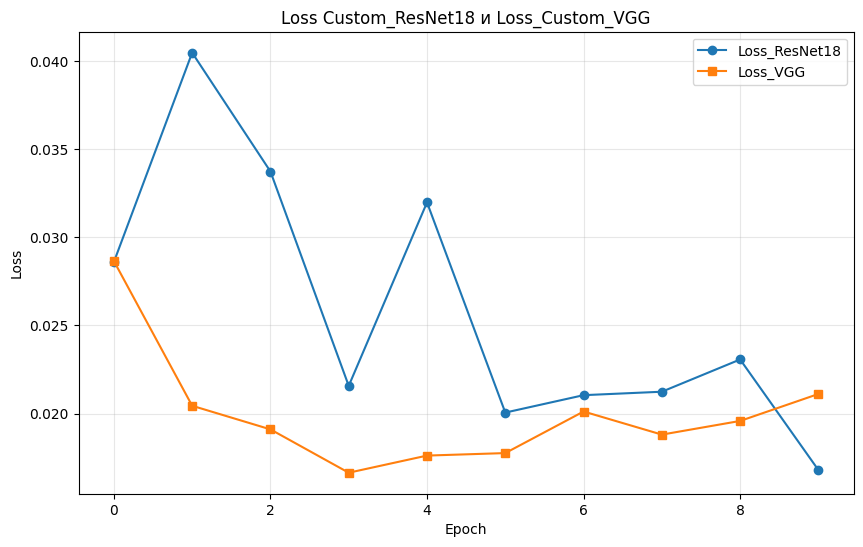

In [39]:
plt.figure(figsize=(10, 6))
plt.plot(df_total['Epoch'], df_total['Validation Loss_Custom_ResNet18'], label='Loss_ResNet18', marker='o')
plt.plot(df_total['Epoch'], df_total['Validation Loss_Custom_VGG'], label='Loss_VGG', marker='s')
plt.title('Loss Custom_ResNet18 и Loss_Custom_VGG')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()